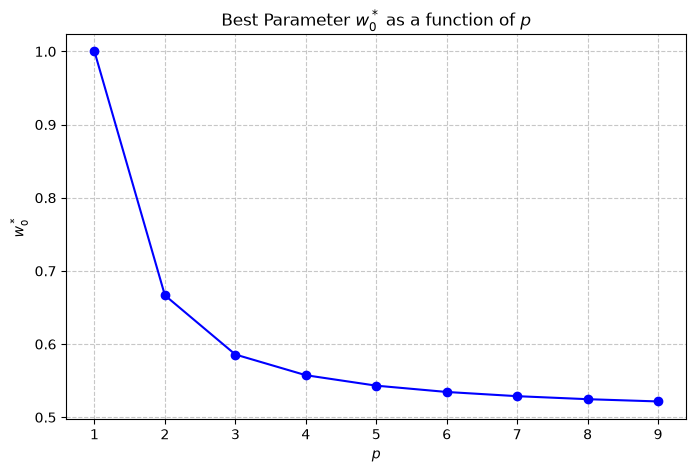

In [56]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

x=np.array([0,1,-1])
y=np.array([0,1,1])
p_vec= np.arange(1,10)

w0_best=[]
w1_best=[]

def lossfunc(w,x,y,p):
    # putting the variable, w, of interest first 
    y_hat=w[0]+w[1]*x
    return np.sum(np.abs(y-y_hat)**p)
for p in p_vec:

    initial_guess=[.0,.0]

    # inputting the arguments that are not minimized
    result=minimize(lossfunc,initial_guess,args=(x,y,p))

    optimal_w0, optimal_w1 = result.x
    w0_best.append(optimal_w0)
    w1_best.append(optimal_w1)

plt.figure(figsize=(8,5))
plt.plot(p_vec, w0_best, marker= 'o',linestyle='-',color='b')
plt.title('Best Parameter $w_0^*$ as a function of $p$')
plt.xlabel('$p$')
plt.ylabel('$w_0^*$')
plt.xticks(p_vec)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## OPG 2

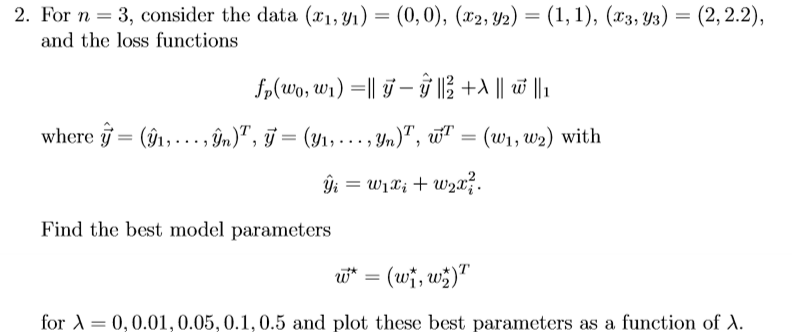

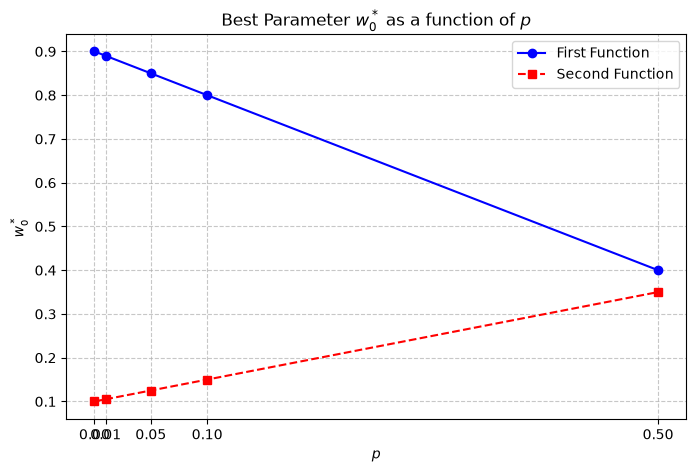

In [57]:
x=np.array([0,1,2])
y=np.array([0,1,2.2])
lamb_vec= np.array([0,0.01,0.05,0.1,0.5])

w0_best=[]
w1_best=[]

def lossfunc(w,x,y,lamb):
    # putting the variable, w, of interest first 
    y_hat=w[0]*x+w[1]*x**2
    return np.sum(np.abs(y-y_hat)**2)+lamb*np.sum(np.abs(w))
for lamb in lamb_vec:

    initial_guess=[.0,.0]

    # inputting the arguments that are not minimized
    result=minimize(lossfunc,initial_guess,args=(x,y,lamb))

    optimal_w0, optimal_w1 = result.x
    w0_best.append(optimal_w0)
    w1_best.append(optimal_w1)

plt.figure(figsize=(8,5))

# First function
plt.plot(lamb_vec, w0_best, marker='o', linestyle='-', color='b', label='First Function')

# Second function (replace 'w0_alt' with your actual second variable)
plt.plot(lamb_vec, w1_best, marker='s', linestyle='--', color='r', label='Second Function')

plt.title('Best Parameter $w_0^*$ as a function of $p$')
plt.xlabel('$p$')
plt.ylabel('$w_0^*$')
plt.xticks(lamb_vec)
plt.grid(True, linestyle='--', alpha=0.7)

# Add a legend so you can tell the lines apart
plt.legend()

plt.show()

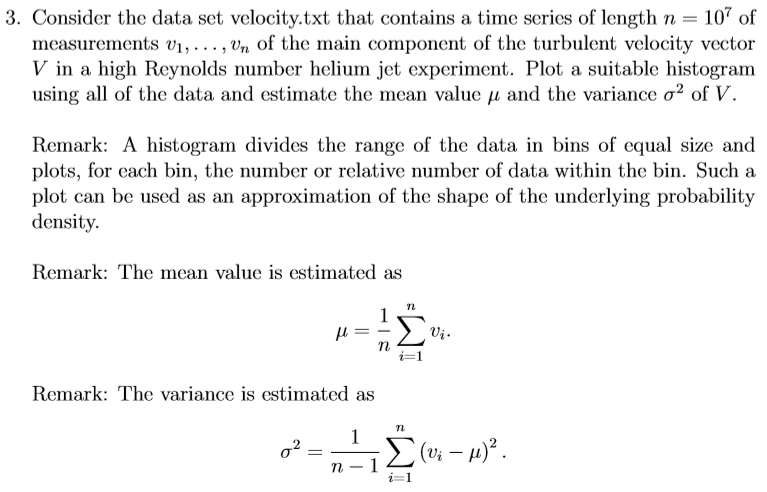

4.975 1.125
4.976493658000001 1.1713968898578189


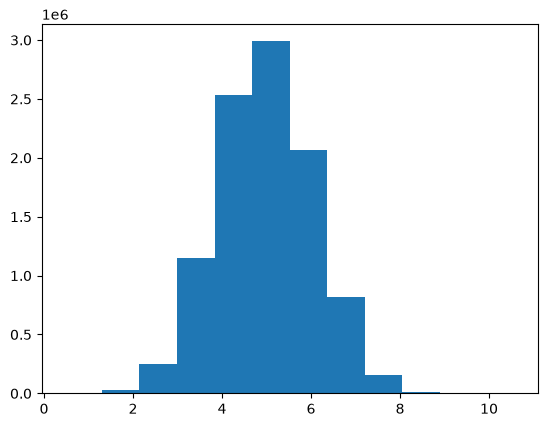

In [ ]:
velo=np.loadtxt('Data/velocity.txt')
n=np.size(velo)

mean=np.sum(velo)/n
var=1/(n-1)*np.sum((velo-mean)**2)
plt.hist(velo,12)
print(round(mean,3), round(var,3))


## opg4
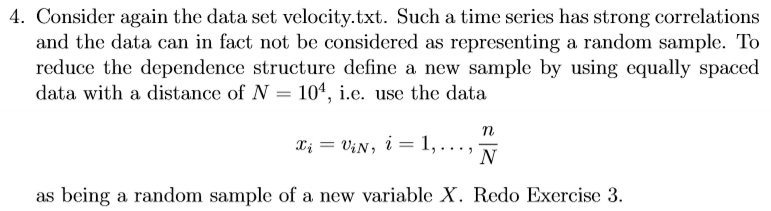

1000
4.996 1.128
(1000,)
4.976493658000001 1.1713968898578189


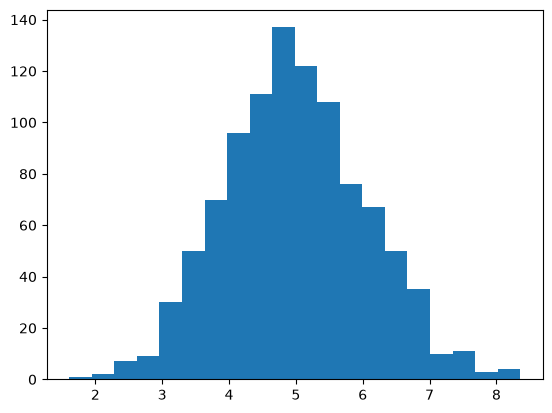

In [ ]:
import numpy as np

N = 10**4
gap = n / N
print(int(gap))
n = int(n)

# FIX 1: Add dtype=int to force the generated indices to be integers
idx = np.linspace(0, n, int(gap), dtype=int)

v_new = velo[idx[0:-1]]

n2=np.size(v_new)

mean=np.sum(v_new)/n2
var=1/(n2-1)*np.sum((v_new-mean)**2)
plt.hist(v_new,20)
print(round(mean,3), round(var,3))

x = velo[N-1::N] 


    # 3. Estimate the mean and variance
    # The variance formula in Exercise 3 uses (n-1) in the denominator, so ddof=1 is required.
mu2 = np.mean(x)
sigma_squared2 = np.var(x, ddof=1)
print(mu2, sigma_squared2)

## opg5
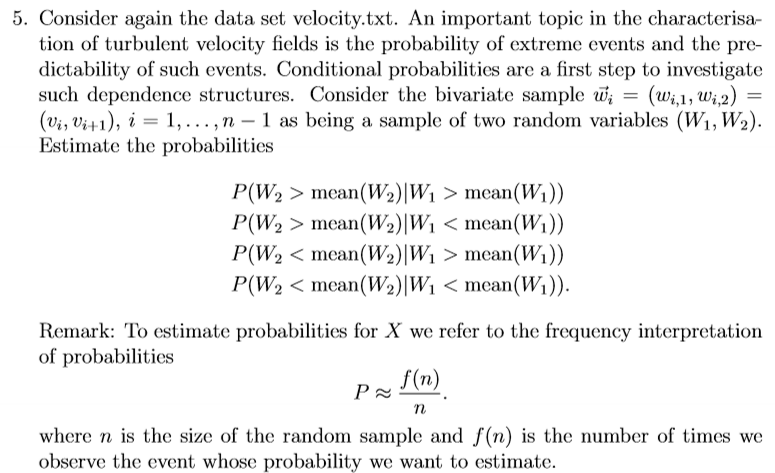

In [87]:
v=velo[0:-1]
v_p=velo[1:]

mat=np.vstack((v,v_p))
print(np.shape(mat))

v_mean=np.sum(v)/(n-1)
v_p_mean=np.sum(v_p)/(n-1)


P_W2_larger=np.sum(v_p[:]>v_p_mean)/(n-1)
P_W2_smaller=1-P_W2_larger
P_W1_larger=np.sum(v[:]>v_mean)/(n-1)
P_W1_smaller=1-P_W1_larger

# P_W1L_W2L=(np.sum(P_W1_larger*P_W2_larger))/ (n-1) / np.sum(P_W1_larger)
# print(P_W1L_W2L)
# FIX: Find where BOTH conditions are true using boolean array intersection (&)
# P(W2 > mean | W1 > mean) = Count(W1 > mean AND W2 > mean) / Count(W1 > mean)
intersection_count = np.sum((v > v_mean) & (v_p > v_p_mean))
condition_count = np.sum(v > v_mean)

P_W1L_W2L = intersection_count / condition_count
print(P_W1L_W2L)

intersection_count = np.sum((v > v_mean) & (v_p < v_p_mean))
condition_count = np.sum(v < v_mean)

P_W1S_W2L = intersection_count / condition_count
print(P_W1S_W2L)

intersection_count = np.sum((v < v_mean) & (v_p > v_p_mean))
condition_count = np.sum(v > v_mean)

P_W1S_W2L = intersection_count / condition_count
print(P_W1S_W2L)

intersection_count = np.sum((v < v_mean) & (v_p < v_p_mean))
condition_count = np.sum(v < v_mean)

P_W1L_W2S = intersection_count / condition_count
print(P_W1L_W2S)


(2, 9999999)
0.9794080406755947
0.020244599437187285
0.020591959324405256
0.9797554005628127


## opg6

In [ ]:
import numpy as np

# Assuming 'velo' is your loaded 1D array
N = 10**4

# Recreate the W1 (v) and W2 (v_p) arrays from Exercise 5
v = velo[:-1]
v_p = velo[1:]

# Subsample to create U1 and U2
# The math notation i=1, 2, ... means we start at index N and step by N.
# (If you are expected to start at the 0th index, use v[::N] instead)
U1 = v[N::N]
U2 = v_p[N::N]

print(f"Original array size: {len(v)}")
print(f"Subsampled array size: {len(U1)}")

# --- Next Steps ---
# The prompt states: "Redo Exercise 3 using..."
# Apply the exact same logic/code you wrote for Exercise 3, but use U1 and U2 
# instead of your original velocity arrays.

# If the assignment contains a typo and meant "Redo Exercise 5", 
# simply apply the conditional probability logic to U1 and U2:
u1_mean = np.mean(U1)
u2_mean = np.mean(U2)

# Example: P(U2 > mean(U2) | U1 > mean(U1))
intersection = np.sum((U1 > u1_mean) & (U2 > u2_mean))
condition = np.sum(U1 > u1_mean)
prob = intersection / condition
print(f"Conditional Probability: {prob}")


# # Example: P(U2 > mean(U2) | U1 < mean(U1)) These are wrong
# intersection = np.sum((U1 < u1_mean) & (U2 > u2_mean)) /(len(U1)+1)
# condition = np.sum(U1 < u1_mean) /len(U1)
# prob = intersection / condition
# print(f"Conditional Probability: {prob}")

# Example: P(U2 < mean(U2) | U1 > mean(U1))
intersection = np.sum((U1 > u1_mean) & (U2 < u2_mean))
condition = np.sum(U1 > u1_mean)
prob = intersection / condition
print(f"Conditional Probability: {prob}")

# # Example: P(U2 < mean(U2) | U1 < mean(U1)) ##Wrong
# intersection = np.sum((U1 < u1_mean) & (U2 < u2_mean))
# condition = np.sum(U1 < u1_mean)
# prob = intersection / condition
# print(f"Conditional Probability: {prob}")

Original array size: 9999999
Subsampled array size: 999
Conditional Probability: 0.9774127310061602
Conditional Probability: 0.042925781249999996
Conditional Probability: 0.022587268993839837
Conditional Probability: 0.95703125
